169001437/169001437 [==============================] - 2s 0us/step
Epoch 1/100
313/313 [==============================] - 35s 65ms/step - loss: 0.0100 - val_loss: 0.0059
Epoch 2/100
313/313 [==============================] - 17s 53ms/step - loss: 0.0039 - val_loss: 0.0065
Epoch 3/100
313/313 [==============================] - 17s 54ms/step - loss: 0.0032 - val_loss: 0.0032
Epoch 4/100
313/313 [==============================] - 17s 55ms/step - loss: 0.0024 - val_loss: 0.0027
Epoch 5/100
313/313 [==============================] - 19s 60ms/step - loss: 0.0021 - val_loss: 0.0029
Epoch 6/100
313/313 [==============================] - 18s 57ms/step - loss: 0.0019 - val_loss: 0.0022
Epoch 7/100
313/313 [==============================] - 19s 61ms/step - loss: 0.0018 - val_loss: 0.0019
Epoch 8/100
313/313 [==============================] - 19s 62ms/step - loss: 0.0016 - val_loss: 0.0017
Epoch 9/100
313/313 [==============================] - 18s 58ms/step - loss: 0.0015 - val_loss: 0.0018
Epoch 

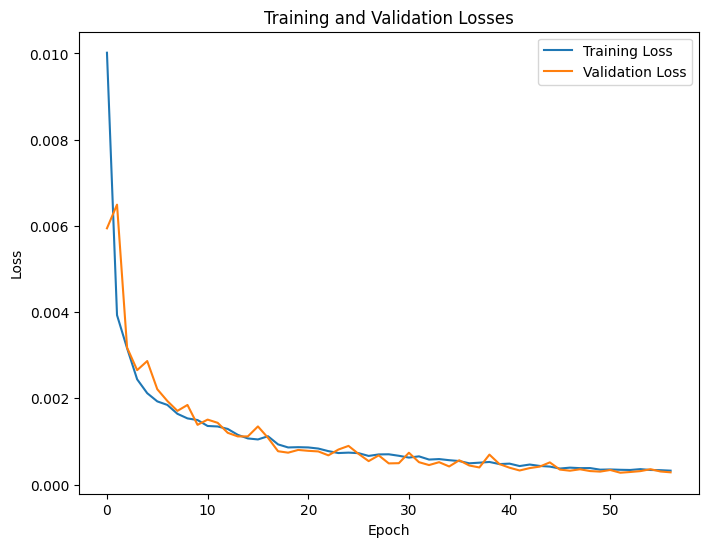

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


313/313 [==============================] - 1s 2ms/step
Metrics for Test Dataset:
Test MSE: 0.0003
Test MAE: 0.0122
Test PSNR: 35.39
Test SSIM: 1.00


In [3]:
from tensorflow.keras.datasets import cifar100
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Reshape, Conv2D, MaxPooling2D, UpSampling2D, Conv2DTranspose, BatchNormalization, Activation, Add
from tensorflow.keras.optimizers import Adam
import numpy as np
import matplotlib.pyplot as plt
import cv2
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.callbacks import EarlyStopping

# Load the CIFAR100 dataset
(x_train, _), (x_test, _) = cifar100.load_data()

# Preprocess data
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
val_size = 0.2
val_index = int(len(x_train) * (1 - val_size))
x_val = x_train[val_index:]
x_train = x_train[:val_index]

# Define the ResNet50 encoder
input_img = Input(shape=(32, 32, 3))

# First ResNet block
x = Conv2D(64, (3, 3), padding='same', kernel_initializer='he_normal')(input_img)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Conv2D(64, (3, 3), padding='same', kernel_initializer='he_normal')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
shortcut = x
x = Conv2D(64, (3, 3), strides=(2, 2), padding='same', kernel_initializer='he_normal')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
shortcut = Conv2D(64, (1, 1), strides=(2, 2), padding='same', kernel_initializer='he_normal')(shortcut)
x = Add()([x, shortcut])

# Second ResNet block
x = Conv2D(128, (3, 3), padding='same', kernel_initializer='he_normal')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Conv2D(128, (3, 3), padding='same', kernel_initializer='he_normal')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
shortcut = x
x = Conv2D(128, (3, 3), strides=(2, 2), padding='same', kernel_initializer='he_normal')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
shortcut = Conv2D(128, (1, 1), strides=(2, 2), padding='same', kernel_initializer='he_normal')(shortcut)
x = Add()([x, shortcut])

# Third ResNet block
x = Conv2D(256, (3, 3), padding='same', kernel_initializer='he_normal')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Conv2D(256, (3, 3), padding='same', kernel_initializer='he_normal')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
shortcut = x
x = Conv2D(256, (3, 3), strides=(2, 2), padding='same', kernel_initializer='he_normal')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
shortcut = Conv2D(256, (1, 1), strides=(2, 2), padding='same', kernel_initializer='he_normal')(shortcut)
x = Add()([x, shortcut])

encoded = x

# Create the encoder model
encoder = Model(inputs=input_img, outputs=encoded)

# Define the input shape for the decoder
input_shape = (4, 4, 256)  # Adjust this based on the encoder output shape

# Define the decoder layers
decoder_input = Input(shape=input_shape)
x = Conv2DTranspose(128, (3, 3), strides=(2, 2), padding='same', activation='relu')(decoder_input)
x = Conv2DTranspose(64, (3, 3), strides=(2, 2), padding='same', activation='relu')(x)
x = Conv2DTranspose(3, (3, 3), strides=(2, 2), padding='same', activation='sigmoid')(x)

# Create the decoder model
decoder = Model(inputs=decoder_input, outputs=x)

# Connect the encoder and decoder
inputs = Input(shape=(32, 32, 3))
encoded = encoder(inputs)
decoded = decoder(encoded)

# Create the autoencoder model
autoencoder = Model(inputs=inputs, outputs=decoded)

# Compile the autoencoder model
autoencoder.compile(optimizer=Adam(), loss='mse')

# Define early stopping callback
early_stop = EarlyStopping(monitor='val_loss', patience=5)

# Train the autoencoder and record training history
history = autoencoder.fit(x_train, x_train, epochs=100, batch_size=128, shuffle=True,
                          validation_data=(x_val, x_val), callbacks=[early_stop])

# Plot training and validation losses
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Losses')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Save the model
autoencoder.save('/content/drive/MyDrive/Colab Notebooks/DLSIP_project/resnet50_model.h5')

# Encode and reconstruct the test images
test_encoded = encoder.predict(x_test)
test_reconstructed = decoder.predict(test_encoded)

test_mse = mean_squared_error(x_test.reshape(x_test.shape[0], -1), test_reconstructed.reshape(test_reconstructed.shape[0], -1))
test_mae = np.mean(np.abs(x_test.reshape(x_test.shape[0], -1) - test_reconstructed.reshape(test_reconstructed.shape[0], -1)))
test_psnr = peak_signal_noise_ratio(x_test, test_reconstructed, data_range=1.0)
test_ssim = structural_similarity(x_test, test_reconstructed, channel_axis=-1, data_range=1.0)

print("Metrics for Test Dataset:")
print(f"Test MSE: {test_mse:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print(f"Test PSNR: {test_psnr:.2f}")
print(f"Test SSIM: {test_ssim:.2f}")

## **Sender**

In [4]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.callbacks import EarlyStopping
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
from sklearn.metrics import mean_squared_error

# Load and preprocess the input image
image_path = '/content/drive/MyDrive/Colab Notebooks/DLSIP_project/Screenshot 2023-12-12 201012.png'
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
original_image = image.copy()
img = cv2.resize(image, (32, 32))
img = np.expand_dims(img, axis=0) / 255.0

# Load the saved model
loaded_model = load_model('/content/drive/MyDrive/Colab Notebooks/DLSIP_project/resnet50_model.h5')

# Extract the semantic features
semantic_features = encoder.predict(img)

print(semantic_features)
print(semantic_features.size)

1/1 [==============================] - 1s 648ms/step
[[[[ 0.10326244  1.7142458  -0.319501   ... -2.7769759   1.3997751
     2.5222461 ]
   [ 0.51473254  0.2275927   1.5745705  ... -0.42741978 -0.30118573
     0.7813309 ]
   [ 0.5357752   0.7767053  -0.37723553 ... -0.1833893   1.1100007
     1.8694146 ]
   [-0.2807143   0.3320138  -0.3412521  ... -0.47642767  0.63523424
     1.9528961 ]]

  [[-0.2148318   1.2838522  -0.68157804 ... -1.0645965   0.83898646
     3.4991992 ]
   [-0.5719018  -0.3151571  -0.17564337 ... -1.0139234  -1.4328996
     0.604998  ]
   [ 0.52913254 -3.0637624   1.039613   ... -0.7156241  -0.49746096
     1.1609263 ]
   [-0.18737191 -1.6213473   1.7240558  ...  0.5909083  -1.5204915
     2.035221  ]]

  [[ 0.6879347  -0.4833995  -0.58160037 ... -1.6960105   1.2573849
     3.6862092 ]
   [-0.24689636  0.94746614 -1.6856785  ... -0.77325594  0.6630527
     2.542615  ]
   [-0.03558163  1.0936973  -2.2475424  ... -1.3493216   0.60112524
     1.7409277 ]
   [ 0.7932587

# **Steganography**

### **Converting Semantic Features to JSON format**

In [5]:
import json
import numpy as np

# Convert numpy array to list before serializing to JSON
sample_semantic_features_list = semantic_features.tolist()

# Serialize the semantic features to a JSON string
sample_semantic_features_json = json.dumps(sample_semantic_features_list)

print("String representation of semantic features:")
print(sample_semantic_features_json)

String representation of semantic features:
[[[[0.10326243937015533, 1.7142457962036133, -0.31950101256370544, 0.6928390264511108, -0.41013824939727783, 0.8039633631706238, -1.4937903881072998, 0.05253690481185913, -2.3973844051361084, -0.49444323778152466, 0.14379698038101196, 1.4846076965332031, 0.35611408948898315, -1.4297910928726196, -0.24402809143066406, -0.500164270401001, 1.6618633270263672, 1.2687163352966309, 2.423722743988037, 0.013913393020629883, -0.20895177125930786, -0.29544246196746826, 0.833155632019043, 1.5895463228225708, 0.4454505145549774, -1.4279444217681885, 0.2578936815261841, -0.5397500395774841, -1.4618606567382812, 2.1180784702301025, 0.7406465411186218, -1.1697033643722534, 0.26953768730163574, -0.5545395016670227, 0.17832936346530914, -0.14352351427078247, 1.6472094058990479, -1.218881607055664, -0.37258291244506836, -0.9683901071548462, 0.2524760365486145, -0.008612841367721558, -1.1600463390350342, 0.2250237911939621, 1.879305362701416, 1.3061721324920654

### **Embedding Semantic Features**

In [19]:
#CODE 1 - Embedding Message into Input Image and generate sprite image

import cv2
import numpy as np
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
import matplotlib.pyplot as plt
from PIL import Image
import os
import math

def encode_message_length(length):
    # Encode the length of the message as a 32-bit binary string
    return format(length, '032b')

def split_message(message, num_parts):
    # Calculate the length of each part
    part_length = len(message) // num_parts
    # Calculate the number of parts that will have one extra character
    extra_parts = len(message) % num_parts
    # Initialize the starting index for each part
    start_index = 0
    # Split the message into parts
    message_parts = []
    for i in range(num_parts):
        # Calculate the end index for the current part
        end_index = start_index + part_length
        # Adjust the end index if there are extra parts
        if i < extra_parts:
            end_index += 1
        # Add the current part to the list of message parts
        message_parts.append(message[start_index:end_index])
        # Update the starting index for the next part
        start_index = end_index
    return message_parts

def embed_message(input_image_path, message):
    input_image = cv2.imread(input_image_path)
    if input_image is None:
        raise FileNotFoundError(f"Unable to load image: {input_image_path}")

    original_image = input_image.copy()  # Make a copy for comparison

    binary_message = ''.join(format(ord(char), '08b') for char in message)
    message_length = len(binary_message)

    # Check if the message can fit within the image
    max_message_length = (input_image.shape[0] * input_image.shape[1] - 32) // 3
    if message_length > max_message_length:
        raise ValueError(f"Message is too long to embed in the image. Max message length: {max_message_length}")

    # Embed the length of the message into the first 32 pixels
    binary_length = encode_message_length(message_length)
    for i in range(32):
        input_image[i // input_image.shape[1], i % input_image.shape[1]][0] = ((input_image[i // input_image.shape[1], i % input_image.shape[1]][0] >> 1) << 1) | int(binary_length[i])

    # Embed the message into the remaining pixels
    for i in range(32, message_length + 32):
        input_image[i // input_image.shape[1], i % input_image.shape[1]][0] = ((input_image[i // input_image.shape[1], i % input_image.shape[1]][0] >> 1) << 1) | int(binary_message[i - 32])

    return input_image

def find_grid_size(num_images):
    # Find factors of the number of images
    factors = []
    for i in range(1, int(math.sqrt(num_images)) + 1):
        if num_images % i == 0:
            factors.append((i, num_images // i))
    return factors[-1]  # Choose the last factor pair (largest grid)

def create_sprite_image(embedded_images, sprite_image_path):
    num_images = len(embedded_images)
    columns, rows = find_grid_size(num_images)

    max_width = max(img.shape[1] for img in embedded_images)
    max_height = max(img.shape[0] for img in embedded_images)

    sprite_width = max_width * columns
    sprite_height = max_height * rows

    sprite = Image.new("RGB", (sprite_width, sprite_height), (255, 255, 255))

    x_offset = 0
    y_offset = 0
    for img in embedded_images:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        pil_img = Image.fromarray(img)
        sprite.paste(pil_img, (x_offset, y_offset))
        x_offset += max_width
        if x_offset >= sprite_width:
            x_offset = 0
            y_offset += max_height

    sprite.save(sprite_image_path)
    print("Sprite image created successfully!")

# Example usage:
input_image_folder = '/content/drive/MyDrive/Colab Notebooks/DLSIP_project/Monet/monet/'  # Folder containing input images
output_sprite_image_path = '/content/drive/MyDrive/Colab Notebooks/DLSIP_project/new_sprite_image.png'  # Path to save the sprite image
message = sample_semantic_features_json # Secret message to embed
num_parts = 49  # Number of parts to split the message into

# Find the message length
message_length = len(message)
print(f"Message length: {message_length}")

# Split the message into parts
message_parts = split_message(message, num_parts)
print("Message parts:", message_parts)
print(len(message_parts))

# Embed each message part into a different image
embedded_images = []
for i, part in enumerate(message_parts):
    input_image_path = os.path.join(input_image_folder, f"image_{i+1}.jpg")  # Adjust the filename index
    if not os.path.exists(input_image_path):  # Check if the image exists
        continue
    embedded_image = embed_message(input_image_path, part)
    embedded_images.append(embedded_image)

# Create sprite image using the embedded images
create_sprite_image(embedded_images, output_sprite_image_path)

Message length: 84314
Message parts: ['[[[[0.10326243937015533, 1.7142457962036133, -0.31950101256370544, 0.6928390264511108, -0.41013824939727783, 0.8039633631706238, -1.4937903881072998, 0.05253690481185913, -2.3973844051361084, -0.49444323778152466, 0.14379698038101196, 1.4846076965332031, 0.35611408948898315, -1.4297910928726196, -0.24402809143066406, -0.500164270401001, 1.6618633270263672, 1.2687163352966309, 2.423722743988037, 0.013913393020629883, -0.20895177125930786, -0.29544246196746826, 0.833155632019043, 1.5895463228225708, 0.4454505145549774, -1.4279444217681885, 0.2578936815261841, -0.5397500395774841, -1.4618606567382812, 2.1180784702301025, 0.7406465411186218, -1.1697033643722534, 0.26953768730163574, -0.5545395016670227, 0.17832936346530914, -0.14352351427078247, 1.6472094058990479, -1.218881607055664, -0.37258291244506836, -0.9683901071548462, 0.2524760365486145, -0.008612841367721558, -1.1600463390350342, 0.2250237911939621, 1.879305362701416, 1.3061721324920654, 0.6

### **Retreiving Semantic Features**

In [24]:

#CODE 2 - Segment Sprite image and extract message from steg images

def extract_message(steganographed_image_path):
    image_with_message = cv2.imread(steganographed_image_path)

    # Check if the image loading was successful
    if image_with_message is None:
        print("Failed to load the steganographed image.")
        return None

    # Extract the length of the message from the first 32 pixels
    binary_length = ''
    for i in range(32):
        binary_length += str(image_with_message[i // image_with_message.shape[1], i % image_with_message.shape[1]][0] & 1)

    message_length = int(binary_length, 2)

    # Check if there is a message embedded in the image
    if message_length == 0:
        print("No message found in the steganographed image.")
        return None

    # Extract the message from the remaining pixels
    binary_message = ''
    for i in range(32, message_length + 32):
        if i // image_with_message.shape[1] < image_with_message.shape[0]:  # Check if the index is within image dimensions
            binary_message += str(image_with_message[i // image_with_message.shape[1], i % image_with_message.shape[1]][0] & 1)

    message = ''
    for i in range(0, len(binary_message), 8):
        message += chr(int(binary_message[i:i+8], 2))

    return message


import cv2
import numpy as np
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
import matplotlib.pyplot as plt
from PIL import Image
import os
import math


def segment_sprite_image_with_message_extraction(sprite_image_path, output_folder, rows, columns, image_width, image_height):
    # Open sprite image
    sprite = Image.open(sprite_image_path)

    # Create output folder if it doesn't exist
    os.makedirs(output_folder, exist_ok=True)

    extracted_parts = []  # Store extracted parts for later reconstruction

    # Segment the sprite image into individual images and extract message parts
    for row in range(rows):
        for col in range(columns):
            x_offset = col * image_width
            y_offset = row * image_height
            cropped_img = sprite.crop((x_offset, y_offset, x_offset + image_width, y_offset + image_height))
            filename = f"image_{row * columns + col + 1}.png"
            cropped_img.save(os.path.join(output_folder, filename))
            print(f"Segmented image {filename} saved at position (row={row}, col={col})")

            # Extract message part from the segmented image
            extracted_part = extract_message(os.path.join(output_folder, filename))
            print(f"Extracted part from {filename}: {extracted_part}")
            if extracted_part:
                extracted_parts.append(extracted_part)

    # Concatenate extracted parts to reconstruct the message
    reconstructed_message = "".join(extracted_parts).strip()
    return reconstructed_message

# Example usage
sprite_image_path = "/content/drive/MyDrive/Colab Notebooks/DLSIP_project/new_sprite_image.png"
output_folder = "/content/drive/MyDrive/Colab Notebooks/DLSIP_project/Monetrecover"
rows = 7  # Number of rows in the grid
columns = 7  # Number of columns in the grid
image_width = 256  # Width of each individual image within the sprite
image_height = 256  # Height of each individual image within the sprite

# Segment sprite image into individual steganographed images and extract message parts
reconstructed_msg = segment_sprite_image_with_message_extraction(sprite_image_path, output_folder, rows, columns, image_width, image_height)

Segmented image image_1.png saved at position (row=0, col=0)
Extracted part from image_1.png: [[[[0.10326243937015533, 1.7142457962036133, -0.31950101256370544, 0.6928390264511108, -0.41013824939727783, 0.8039633631706238, -1.4937903881072998, 0.05253690481185913, -2.3973844051361084, -0.49444323778152466, 0.14379698038101196, 1.4846076965332031, 0.35611408948898315, -1.4297910928726196, -0.24402809143066406, -0.500164270401001, 1.6618633270263672, 1.2687163352966309, 2.423722743988037, 0.013913393020629883, -0.20895177125930786, -0.29544246196746826, 0.833155632019043, 1.5895463228225708, 0.4454505145549774, -1.4279444217681885, 0.2578936815261841, -0.5397500395774841, -1.4618606567382812, 2.1180784702301025, 0.7406465411186218, -1.1697033643722534, 0.26953768730163574, -0.5545395016670227, 0.17832936346530914, -0.14352351427078247, 1.6472094058990479, -1.218881607055664, -0.37258291244506836, -0.9683901071548462, 0.2524760365486145, -0.008612841367721558, -1.1600463390350342, 0.22502

### **Converting Semantic Features back to numpy array**

In [25]:
import json
import numpy as np

# JSON string representation of semantic features
semantic_features_json = reconstructed_msg

# Deserialize the semantic features from the JSON string
semantic_features_list = json.loads(semantic_features_json)

# Convert the list back to a numpy array
semantic_features_reconstructed = np.array(semantic_features_list)

print("Reconstructed Semantic Features:")
print(semantic_features_reconstructed)
print(semantic_features_reconstructed.size)

Reconstructed Semantic Features:
[[[[ 0.10326244  1.7142458  -0.31950101 ... -2.77697587  1.39977515
     2.52224612]
   [ 0.51473254  0.22759271  1.57457054 ... -0.42741978 -0.30118573
     0.78133088]
   [ 0.53577518  0.77670532 -0.37723553 ... -0.18338931  1.11000073
     1.86941457]
   [-0.2807143   0.33201379 -0.34125209 ... -0.47642767  0.63523424
     1.95289612]]

  [[-0.2148318   1.28385222 -0.68157804 ... -1.06459653  0.83898646
     3.49919915]
   [-0.5719018  -0.31515709 -0.17564337 ... -1.01392341 -1.43289959
     0.60499799]
   [ 0.52913254 -3.06376243  1.03961301 ... -0.71562409 -0.49746096
     1.16092634]
   [-0.18737191 -1.62134731  1.72405577 ...  0.59090829 -1.52049148
     2.0352211 ]]

  [[ 0.6879347  -0.48339951 -0.58160037 ... -1.69601047  1.2573849
     3.6862092 ]
   [-0.24689636  0.94746614 -1.68567848 ... -0.77325594  0.66305268
     2.54261494]
   [-0.03558163  1.09369731 -2.24754238 ... -1.3493216   0.60112524
     1.7409277 ]
   [ 0.79325873  0.30148208 -

## **Reciever**

1/1 [==============================] - 0s 110ms/step

Metrics for Input Image: (between resized and reconstructed image)
Input MSE: 0.0012
Input MAE: 0.0241
Input PSNR: 29.13
Input SSIM: 0.96


<ipython-input-26-7e8c6cee22c0>:27: FutureWarning: `multichannel` is a deprecated argument name for `structural_similarity`. It will be removed in version 1.0. Please use `channel_axis` instead.
  input_ssim = structural_similarity(original_image, resized_reconstructed_image, multichannel=True, data_range=255)



Metrics for Input Image (between original image and resized reconstructed image):
Input MSE: 56.3326
Input MAE: 103.3616
Input PSNR: 22.62
Input SSIM: 0.8706


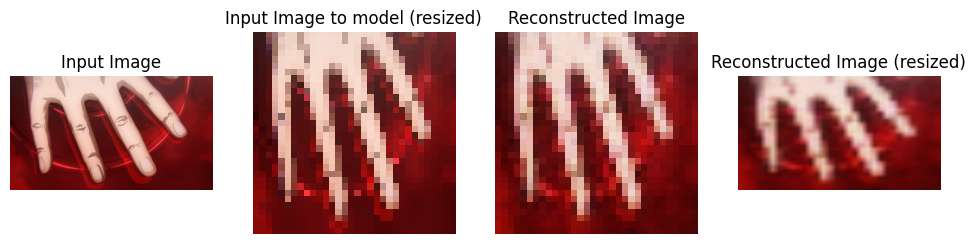

In [26]:
# Reconstruct the image using the semantic features
reconstructed_image = decoder.predict(semantic_features_reconstructed)

# Compute metrics for input image
reconstructed_image_flat = np.squeeze(reconstructed_image).reshape(-1, 3)
img_flat = img.reshape(-1, 3)

input_mse = mean_squared_error(img_flat, reconstructed_image_flat)
input_mae = np.mean(np.abs(img_flat - reconstructed_image_flat))
input_psnr = peak_signal_noise_ratio(img_flat, reconstructed_image_flat, data_range=1.0)
input_ssim = structural_similarity(img_flat, reconstructed_image_flat, channel_axis=-1, data_range=1.0)

print("\nMetrics for Input Image: (between resized and reconstructed image)")
print(f"Input MSE: {input_mse:.4f}")
print(f"Input MAE: {input_mae:.4f}")
print(f"Input PSNR: {input_psnr:.2f}")
print(f"Input SSIM: {input_ssim:.2f}")

# Resize the reconstructed image back to the original size
resized_reconstructed_image = cv2.resize(np.squeeze(reconstructed_image) * 255, (original_image.shape[1], original_image.shape[0]))
resized_reconstructed_image = resized_reconstructed_image.astype('uint8')

# Compute metrics for input image compared to original image
input_mse = mean_squared_error(original_image.reshape(-1, 3), resized_reconstructed_image.reshape(-1, 3))
input_mae = np.mean(np.abs(original_image.reshape(-1, 3) - resized_reconstructed_image.reshape(-1, 3)))
input_psnr = peak_signal_noise_ratio(original_image, resized_reconstructed_image, data_range=255)
input_ssim = structural_similarity(original_image, resized_reconstructed_image, multichannel=True, data_range=255)

print("\nMetrics for Input Image (between original image and resized reconstructed image):")
print(f"Input MSE: {input_mse:.4f}")
print(f"Input MAE: {input_mae:.4f}")
print(f"Input PSNR: {input_psnr:.2f}")
print(f"Input SSIM: {input_ssim:.4f}")

# Save the original image
cv2.imwrite('/content/drive/MyDrive/Colab Notebooks/DLSIP_project/SRGAN/original_image1_ResNet50.png', cv2.cvtColor(original_image, cv2.COLOR_RGB2BGR))

# Save the resized reconstructed image
cv2.imwrite('/content/drive/MyDrive/Colab Notebooks/DLSIP_project/SRGAN/resized_reconstructed_image1_ResNet50.png', cv2.cvtColor(resized_reconstructed_image, cv2.COLOR_RGB2BGR))

# Plot the input image, resized input image, and reconstructed image
plt.figure(figsize=(12, 4))
plt.subplot(1, 4, 1)
plt.imshow(original_image)
plt.axis('off')
plt.title('Input Image')

plt.subplot(1, 4, 2)
plt.imshow(img[0])
plt.axis('off')
plt.title('Input Image to model (resized)')

plt.subplot(1, 4, 3)
plt.imshow(np.squeeze(reconstructed_image))
plt.axis('off')
plt.title('Reconstructed Image')

plt.subplot(1, 4, 4)
plt.imshow(resized_reconstructed_image)
plt.axis('off')
plt.title('Reconstructed Image (resized)')

plt.show()